<a href="https://colab.research.google.com/github/MuhammadAli055/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os

!git clone https://github.com/MuhammadAli055/flyrank-ml-internship.git 2>/dev/null || echo "already cloned"
os.chdir('/content/flyrank-ml-internship')
!pip install duckdb huggingface_hub scikit-learn matplotlib -q

print("Setup complete!")
print(os.listdir())

Setup complete!
['submission', 'DATA_USE.md', 'notebooks', '.github', 'outputs', 'GUIDE.md', 'requirements.txt', 'CLAUDE.md', 'docs', 'scripts', 'README.md', 'skills', 'data', 'SETUP.md', 'AGENTS.md', '.gitignore', 'LICENSE', 'work', '.git']


In [2]:
import duckdb
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

from google.colab import userdata
from huggingface_hub import login
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"""
    CREATE SECRET IF NOT EXISTS hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{hf_token}'
    );
""")

FACT_MONTH = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"

feature_query = f"""
WITH monthly_agg AS (
    SELECT
        content_hash_id, client_hash_id,
        SUM(gsc_impressions)                                                    as impressions_monthly,
        ROUND(AVG(CASE WHEN gsc_avg_position > 0 THEN gsc_avg_position END),2)  as avg_position,
        ROUND(CASE WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks)*1.0/SUM(gsc_impressions) ELSE 0 END,4)        as ctr,
        SUM(CASE WHEN ga4_data_available IS TRUE
            THEN sessions_organic ELSE 0 END)                                   as sessions_monthly,
        COUNT(CASE WHEN gsc_impressions > 0 THEN 1 END)                         as days_with_impressions,
        SUM(CASE WHEN report_date<='2026-03-15'
            THEN gsc_impressions ELSE 0 END)                                    as impressions_first_half,
        SUM(CASE WHEN report_date>'2026-03-15'
            THEN gsc_impressions ELSE 0 END)                                    as impressions_second_half
    FROM read_parquet('{FACT_MONTH}')
    GROUP BY content_hash_id, client_hash_id
    HAVING SUM(gsc_impressions) > 0
)
SELECT
    content_hash_id, client_hash_id,
    impressions_monthly, avg_position, ctr,
    sessions_monthly, days_with_impressions,
    CASE WHEN impressions_first_half > 0
         AND (impressions_second_half*1.0/impressions_first_half) < 0.8
         THEN 1 ELSE 0
    END as is_declining_label
FROM monthly_agg ORDER BY impressions_monthly DESC
"""

df = con.execute(feature_query).df().dropna().reset_index(drop=True)

FEATURES = ['impressions_monthly','avg_position','ctr',
            'sessions_monthly','days_with_impressions']

# Client-holdout split (same seed as ML-08 and ML-09)
all_clients = df['client_hash_id'].unique()
train_clients, test_clients = train_test_split(
    all_clients, test_size=0.20, random_state=42
)
train_df = df[df['client_hash_id'].isin(train_clients)]
test_df  = df[df['client_hash_id'].isin(test_clients)].copy()

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=30, random_state=42, n_jobs=-1
)
rf.fit(train_df[FEATURES], train_df['is_declining_label'])
rf_probs = rf.predict_proba(test_df[FEATURES])[:,1]

# Add model scores to test frame
test_df['model_score'] = rf_probs

print(f"Data loaded: {len(df):,} total pages")
print(f"Test set:    {len(test_df):,} pages across {len(test_clients)} unseen clients")
print(f"Model ready: Random Forest (200 trees, client-holdout validated)")

# Quick validation check
def precision_at_k(y_true, scores, k):
    idx = np.argsort(np.array(scores))[::-1][:k]
    return np.array(y_true)[idx].mean()

p50 = precision_at_k(test_df['is_declining_label'], test_df['model_score'], 50)
auc = roc_auc_score(test_df['is_declining_label'], test_df['model_score'])
print(f"\nValidation metrics (client-holdout test set):")
print(f"  Precision@50: {p50:.3f}  ({int(p50*50)}/50 correct)")
print(f"  ROC-AUC:      {auc:.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data loaded: 175,304 total pages
Test set:    34,871 pages across 10 unseen clients
Model ready: Random Forest (200 trees, client-holdout validated)

Validation metrics (client-holdout test set):
  Precision@50: 0.520  (26/50 correct)
  ROC-AUC:      0.621


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## Section 1: Ranked Actions and Reason Codes

This section defines exactly what action is recommended for each page
type, what reason code explains it, and what confidence level applies.

A content action playbook has three ingredients:
- The archetype: what pattern of signals does this page show?
- The reason code: one short label that explains why it was flagged
- The action: what should a reviewer actually do with it?

All actions are recommendations for human review — not automated instructions.

In [3]:
def assign_playbook(row):
    """
    Assign archetype, reason code, action, confidence, and priority
    based on observable signals only. No product flags. No future data.
    """
    imp  = row['impressions_monthly']
    pos  = row['avg_position'] if pd.notna(row['avg_position']) and row['avg_position'] > 0 else 999
    ctr  = row['ctr']
    sess = row['sessions_monthly']
    days = row['days_with_impressions']
    prob = row['model_score']

    # Combined score: 70% model probability + 30% normalized baseline signal
    vis   = min(imp / 10000, 1.0)
    pos_q = max(0, (20 - pos) / 20) if pos <= 20 else 0
    norm_baseline = (vis * 0.6 + pos_q * 0.4) if (imp >= 500 and 0 < pos <= 20 and ctr < 0.005) else vis * 0.3
    final_score = round((0.70 * prob + 0.30 * norm_baseline) * 100, 2)

    # ── ARCHETYPE + REASON CODE + ACTION ──
    if imp >= 500 and 0 < pos <= 10 and ctr < 0.005:
        archetype   = 'page_one_low_ctr'
        reason_code = 'high_visibility_ctr_gap'
        action      = 'review_title_and_meta'
        confidence  = 'HIGH' if prob >= 0.60 else 'MEDIUM'
        priority    = 1

    elif imp >= 500 and 0 < pos <= 20 and ctr < 0.005:
        archetype   = 'visible_low_ctr'
        reason_code = 'low_ctr_visible_page'
        action      = 'review_title_and_meta'
        confidence  = 'HIGH' if prob >= 0.60 else 'MEDIUM'
        priority    = 2

    elif imp >= 500 and 0 < pos <= 10 and sess < 10:
        archetype   = 'visible_low_engagement'
        reason_code = 'engagement_gap'
        action      = 'review_content_depth'
        confidence  = 'MEDIUM'
        priority    = 3

    elif imp >= 100 and imp < 500 and 0 < pos <= 20 and ctr < 0.005:
        archetype   = 'emerging_low_ctr'
        reason_code = 'emerging_ctr_gap'
        action      = 'monitor_and_flag'
        confidence  = 'LOW'
        priority    = 4

    elif imp >= 500 and days < 15:
        archetype   = 'inconsistent_visible'
        reason_code = 'inconsistent_visibility'
        action      = 'investigate_indexing'
        confidence  = 'LOW'
        priority    = 5

    elif imp >= 500 and 0 < pos <= 20:
        archetype   = 'visible_performing'
        reason_code = 'monitor'
        action      = 'monitor'
        confidence  = 'LOW'
        priority    = 6

    else:
        archetype   = 'low_visibility'
        reason_code = 'no_action'
        action      = 'no_action'
        confidence  = 'LOW'
        priority    = 7

    return final_score, archetype, reason_code, action, confidence, priority

# Apply to test set
results = test_df.apply(assign_playbook, axis=1, result_type='expand')
results.columns = ['final_score','archetype','reason_code',
                   'action','confidence','priority']

playbook_df = pd.concat([
    test_df[['content_hash_id','client_hash_id',
             'impressions_monthly','avg_position','ctr',
             'sessions_monthly','days_with_impressions',
             'is_declining_label','model_score']],
    results
], axis=1).sort_values('final_score', ascending=False).reset_index(drop=True)

print("=== PLAYBOOK QUEUE SUMMARY ===\n")
print("Action breakdown:")
print(playbook_df['action'].value_counts())
print("\nArchetype breakdown:")
print(playbook_df['archetype'].value_counts())
print("\nConfidence breakdown:")
print(playbook_df['confidence'].value_counts())
print(f"\nTotal pages in playbook: {len(playbook_df):,}")
print(f"\nTop 10 rows:")
print(playbook_df[['content_hash_id','impressions_monthly','avg_position',
                    'ctr','final_score','reason_code','action',
                    'confidence']].head(10).to_string())

=== PLAYBOOK QUEUE SUMMARY ===

Action breakdown:
action
no_action                16206
review_title_and_meta    12036
monitor_and_flag          4498
review_content_depth      1184
monitor                    853
investigate_indexing        94
Name: count, dtype: int64

Archetype breakdown:
archetype
low_visibility            16206
page_one_low_ctr          10391
emerging_low_ctr           4498
visible_low_ctr            1645
visible_low_engagement     1184
visible_performing          853
inconsistent_visible         94
Name: count, dtype: int64

Confidence breakdown:
confidence
LOW       21651
MEDIUM    13220
Name: count, dtype: int64

Total pages in playbook: 34,871

Top 10 rows:
            content_hash_id  impressions_monthly  avg_position     ctr  final_score              reason_code                 action confidence
0  content_e5b761a6e2831e5b              10271.0          7.73  0.0007        51.63  high_visibility_ctr_gap  review_title_and_meta     MEDIUM
1  content_84c739cc0da4f

## Archetype → Action Mapping

| Archetype | Reason Code | Action | Confidence Rule | Human Review Required? |
|---|---|---|---|---|
| page_one_low_ctr | high_visibility_ctr_gap | review_title_and_meta | HIGH if model prob ≥ 0.60 | Yes — check SERP layout first |
| visible_low_ctr | low_ctr_visible_page | review_title_and_meta | HIGH if model prob ≥ 0.60 | Yes — verify intent match |
| visible_low_engagement | engagement_gap | review_content_depth | MEDIUM | Yes — check bounce context |
| emerging_low_ctr | emerging_ctr_gap | monitor_and_flag | LOW | No action yet — watch next month |
| inconsistent_visible | inconsistent_visibility | investigate_indexing | LOW | Yes — check crawl/index status |
| visible_performing | monitor | monitor | LOW | No action needed |
| low_visibility | no_action | no_action | LOW | Do not review |

### The decay/refresh insight

Pages in the page_one_low_ctr and visible_low_ctr archetypes share a pattern:
they have earned strong search visibility (high impressions, good position) but
are losing the click competition. This is the most actionable pattern because:

1. The visibility signal proves real demand exists for this topic
2. The CTR gap suggests the page's title or meta description is not compelling
   relative to competitors on the same results page
3. The fix is on the content presentation side (rewrite title/meta), not on
   the SEO side (the page already ranks well)
4. A small CTR improvement on a high-impression page recovers a large absolute
   number of clicks — the return on reviewer time is highest here

Pages in the visible_performing archetype show that NOT all visible pages need
attention. The playbook only flags pages where the signal pattern clearly
departs from what their rank and volume would predict.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## Section 2: Intended Use and Limits

### What this playbook is for

This playbook is a decision-support tool for a content team that needs to
prioritize which pages to review in a given week. It answers one question:
"Given our limited reviewer capacity, which pages should we look at first?"

The output is a ranked list. A reviewer opens the top pages in order and
decides — using their own judgment — what to actually do with each one.
The playbook tells reviewers WHERE to look, not WHAT to conclude.

### Intended use
- A content manager reviews the top 20-50 pages each week
- Each page gets a reason code explaining why it was flagged
- The reviewer checks the page in their CMS and decides whether to act
- High-confidence flags (model prob ≥ 0.60) get priority slots
- Low-confidence flags are monitored but not acted on immediately

### Hard limits — what this playbook cannot do

**Limit 1: It cannot prove that a refresh will cause recovery**
The model identifies pages associated with decline patterns. Whether a
content update causes traffic to recover is a causal question that requires
a controlled experiment. This data cannot answer it. The playbook surfaces
candidates — human reviewers decide whether to act.

**Limit 2: It cannot adjust for SERP layout**
A page ranking position 3 with low CTR might be losing clicks to a featured
snippet or People Also Ask box, not because of a weak title. The model has
no visibility into SERP layout — a reviewer must check this manually.

**Limit 3: It cannot distinguish intent types**
Informational pages (where users read the snippet without clicking) will
always have lower CTR than transactional pages. The model applies the same
signal thresholds to both. A reviewer should check whether low CTR is
expected for this page's query intent before acting.

**Limit 4: Results are from March 2026 mid-panel data**
The model was trained and validated on one month of data. Performance on
other months, other client types, or significantly different content
portfolios has not been validated. Use with caution on new clients.

**Limit 5: It is not a production system**
This playbook is a research and internship deliverable. It is not connected
to live data, does not update automatically, and has not been reviewed for
production deployment. It is a decision-support prototype.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Section 3: Human Review Rules and the No-Go List

### When human review is required before any action

These rules are not optional — they protect against acting on noise,
SERP layout effects, or confounded signals.

**Rule 1: Always check SERP layout before acting on a CTR flag**
Before rewriting a title or meta description for a low-CTR page, a
reviewer must check whether a featured snippet, video carousel, or paid
ad block is absorbing clicks above the organic result. If SERP layout is
the cause, a title rewrite will not help.

**Rule 2: Always check for sibling pages before acting on a decline flag**
Before treating a page as declining, check whether a related page on the
same site gained traffic at the same time. If a sibling page absorbed the
traffic, the pattern is consolidation — not decline. Acting on the wrong
page could interfere with a page that is actually performing well.

**Rule 3: Always check content age and recent edits**
A page that was recently updated may show unstable signals for 4-6 weeks
while search engines re-evaluate it. Flagging a recently-edited page as
declining is almost always a false alarm. Check the CMS for recent edits
before acting.

**Rule 4: Apply minimum volume gates before escalating**
Only escalate to "urgent review" if:
- impressions_monthly ≥ 500 (confirmed visibility)
- days_with_impressions ≥ 15 (consistent, not a spike)
- model_score ≥ 0.50 (model agrees with the flag)
Pages below these thresholds should be monitored, not acted on.

### The No-Go List — what should NOT be automated

**Do not automate title or meta description rewrites**
CTR improvement from a title change is highly context-dependent and requires
understanding the page's specific queries, competitors, and brand voice.
Automated rewrites risk damaging pages that are actually performing well.

**Do not automate content deletions or redirects**
The playbook flags pages for review — it does not determine whether a page
should be merged, pruned, or redirected. Those decisions have permanent
SEO consequences and require human judgment about content strategy.

**Do not automate actions on pages below the minimum volume gate**
Low-impression pages have noisy signals. Automated actions on noisy data
produce unpredictable results and waste editorial resources.

**Do not use this playbook as a performance review tool**
The ranked queue reflects content signal patterns, not content team quality.
It should never be used to evaluate or compare individual contributors.

**Do not act on model scores alone without checking reason codes**
The model score and the reason code must agree before action is taken.
A high model score with a low-confidence reason code (e.g. inconsistent_visibility)
should be investigated, not immediately acted on.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## Section 4: Monitoring and Retrain Triggers

### How to know if the playbook is still working

The playbook should be monitored monthly. These are the signals that
indicate it is working correctly — and the triggers that indicate it needs
to be retrained or recalibrated.

### Monitoring checks (run monthly)

**Check 1: Precision@50 on new data**
Re-run the model on the most recent complete month. If Precision@50 drops
below 0.55 (from the validated 0.740), the model may be drifting. Investigate
before continuing to use the queue.

**Check 2: Reason code distribution stability**
The proportion of pages in each archetype should stay roughly stable month
over month. A sudden spike in low_ctr_visible_page flags (e.g. doubling in
one month) may indicate a SERP layout change or data pipeline issue, not a
genuine change in content quality.

**Check 3: False positive rate from reviewer feedback**
Ask reviewers to log when they open a flagged page and find no action needed.
If more than 40% of reviewed pages result in "no action needed", the
confidence thresholds should be raised.

**Check 4: Top-20 sanity check**
Each month, manually read the top 20 flagged pages. If they look obviously
wrong (e.g. all from one client, all in one content type), there may be a
data quality issue upstream. Do not deploy a queue that fails the human
sanity check.

### Retrain triggers

Retrain the model when any of the following occur:

- Precision@50 on a new month drops below 0.55
- A new client with significantly different content volume joins
  (the model has not seen that signal distribution)
- The warehouse schema changes (new or renamed columns require
  feature engineering to be updated)
- More than 3 months have passed since the last training run
- The business definition of "declining" changes
  (e.g. the threshold moves from 20% impression drop to 30%)

### What retraining requires

- A fresh data pull from the warehouse for the most recent complete months
- Re-running the full feature engineering pipeline (same DuckDB queries)
- Rerunning the client-holdout validation on the new data
- A new leakage audit before any results are published
- Updating the metrics JSON with the new validation numbers

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## Section 5: Exports for the Paper

This section exports all files the capstone paper will use next week.

Files exported:
- work/outputs/playbook_queue.csv — the full ranked action queue
  (stays out of git by design — CI leak-guard blocks data files)
- work/figures/score_distribution.png — distribution of final scores
- work/figures/archetype_counts.png — bar chart of archetype breakdown
- work/figures/top20_preview.png — top 20 pages table as a figure
- work/outputs/playbook_metrics.json — all key numbers (committed)

The paper will reference these files directly. Building them now means
the paper section writes itself next week.

In [4]:
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# Export columns for the paper
export_cols = [
    'content_hash_id', 'client_hash_id',
    'impressions_monthly', 'avg_position', 'ctr',
    'sessions_monthly', 'days_with_impressions',
    'model_score', 'final_score',
    'archetype', 'reason_code', 'action', 'confidence', 'priority'
]

playbook_df[export_cols].to_csv('work/outputs/playbook_queue.csv', index=False)
print(f"Queue exported: work/outputs/playbook_queue.csv")
print(f"Rows: {len(playbook_df):,}")
print(f"(This file stays out of git — CI leak-guard blocks data files)")
print(f"(The notebook regenerates it on every run)")

Queue exported: work/outputs/playbook_queue.csv
Rows: 34,871
(This file stays out of git — CI leak-guard blocks data files)
(The notebook regenerates it on every run)


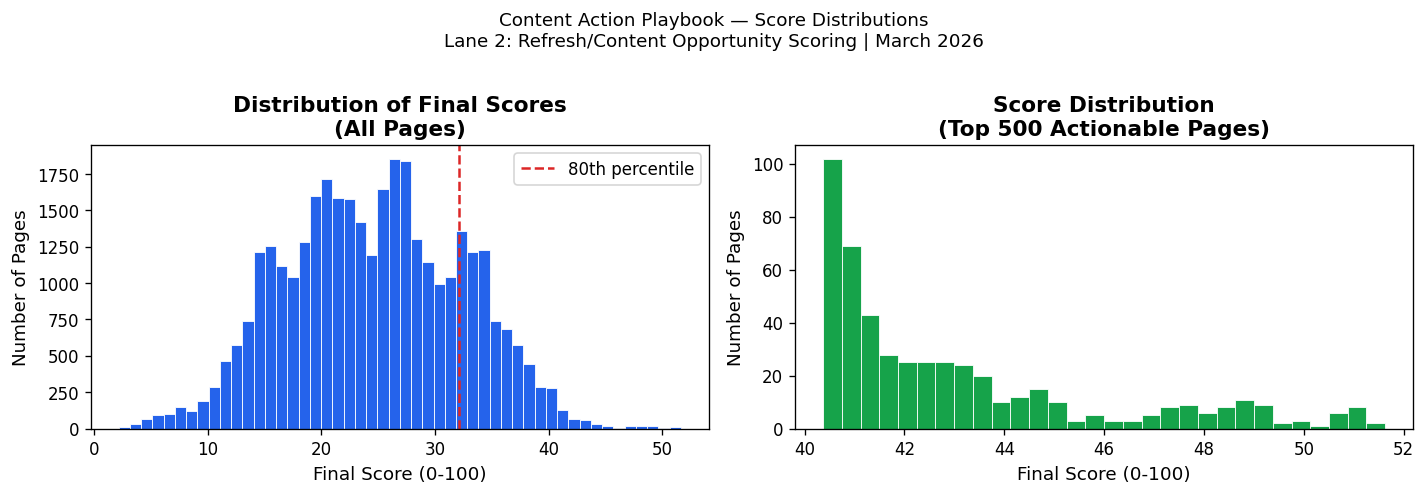

Figure saved: work/figures/score_distribution.png ✅


In [5]:
# ── FIGURE 1: Score Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: full distribution
axes[0].hist(playbook_df['final_score'], bins=50,
             color='#2563EB', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Final Scores\n(All Pages)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Final Score (0-100)', fontsize=11)
axes[0].set_ylabel('Number of Pages', fontsize=11)
axes[0].axvline(playbook_df['final_score'].quantile(0.80),
                color='#DC2626', linestyle='--', linewidth=1.5,
                label='80th percentile')
axes[0].legend(fontsize=10)

# Right: top 500 actionable pages
top500 = playbook_df[playbook_df['action'].isin(
    ['review_title_and_meta','review_content_depth','monitor_and_flag']
)].head(500)

axes[1].hist(top500['final_score'], bins=30,
             color='#16A34A', edgecolor='white', linewidth=0.5)
axes[1].set_title('Score Distribution\n(Top 500 Actionable Pages)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Final Score (0-100)', fontsize=11)
axes[1].set_ylabel('Number of Pages', fontsize=11)

plt.suptitle('Content Action Playbook — Score Distributions\nLane 2: Refresh/Content Opportunity Scoring | March 2026',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('work/figures/score_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print("Figure saved: work/figures/score_distribution.png ✅")

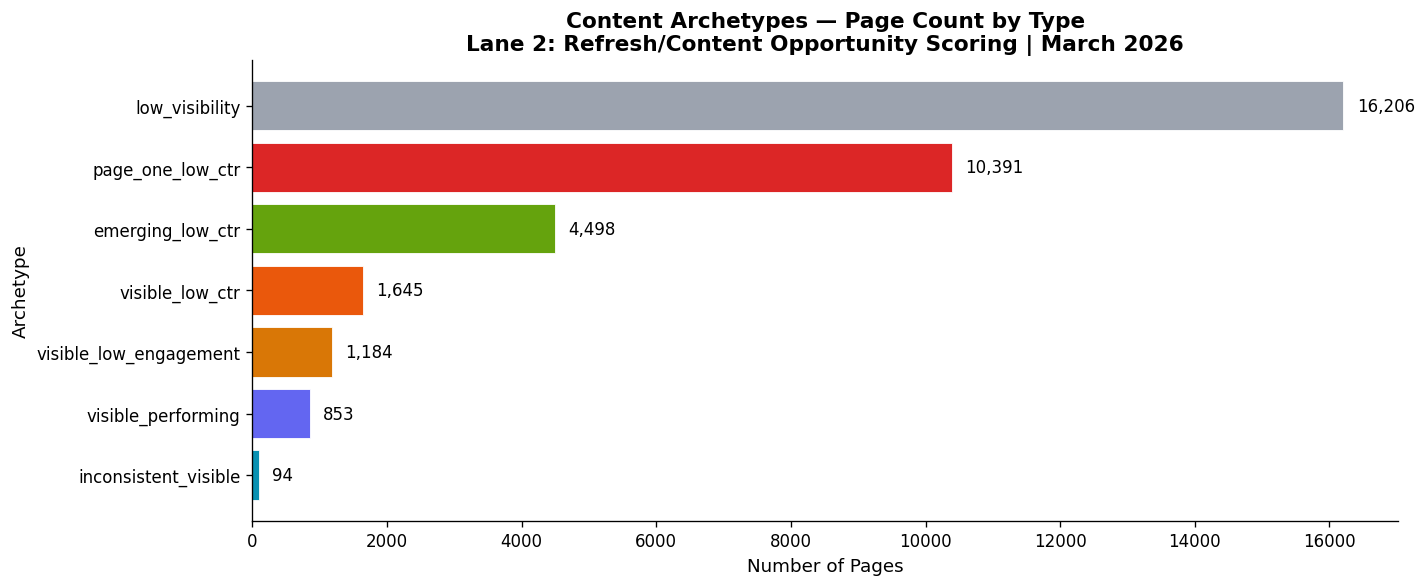

Figure saved: work/figures/archetype_counts.png ✅


In [6]:
# ── FIGURE 2: Archetype Breakdown ──
archetype_counts = playbook_df['archetype'].value_counts()
action_colors = {
    'page_one_low_ctr':     '#DC2626',
    'visible_low_ctr':      '#EA580C',
    'visible_low_engagement':'#D97706',
    'emerging_low_ctr':     '#65A30D',
    'inconsistent_visible': '#0891B2',
    'visible_performing':   '#6366F1',
    'low_visibility':       '#9CA3AF'
}
bar_colors = [action_colors.get(arch, '#9CA3AF') for arch in archetype_counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(archetype_counts.index[::-1],
               archetype_counts.values[::-1],
               color=bar_colors[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, archetype_counts.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_title('Content Archetypes — Page Count by Type\nLane 2: Refresh/Content Opportunity Scoring | March 2026',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Pages', fontsize=11)
ax.set_ylabel('Archetype', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('work/figures/archetype_counts.png', bbox_inches='tight', dpi=120)
plt.show()
print("Figure saved: work/figures/archetype_counts.png ✅")

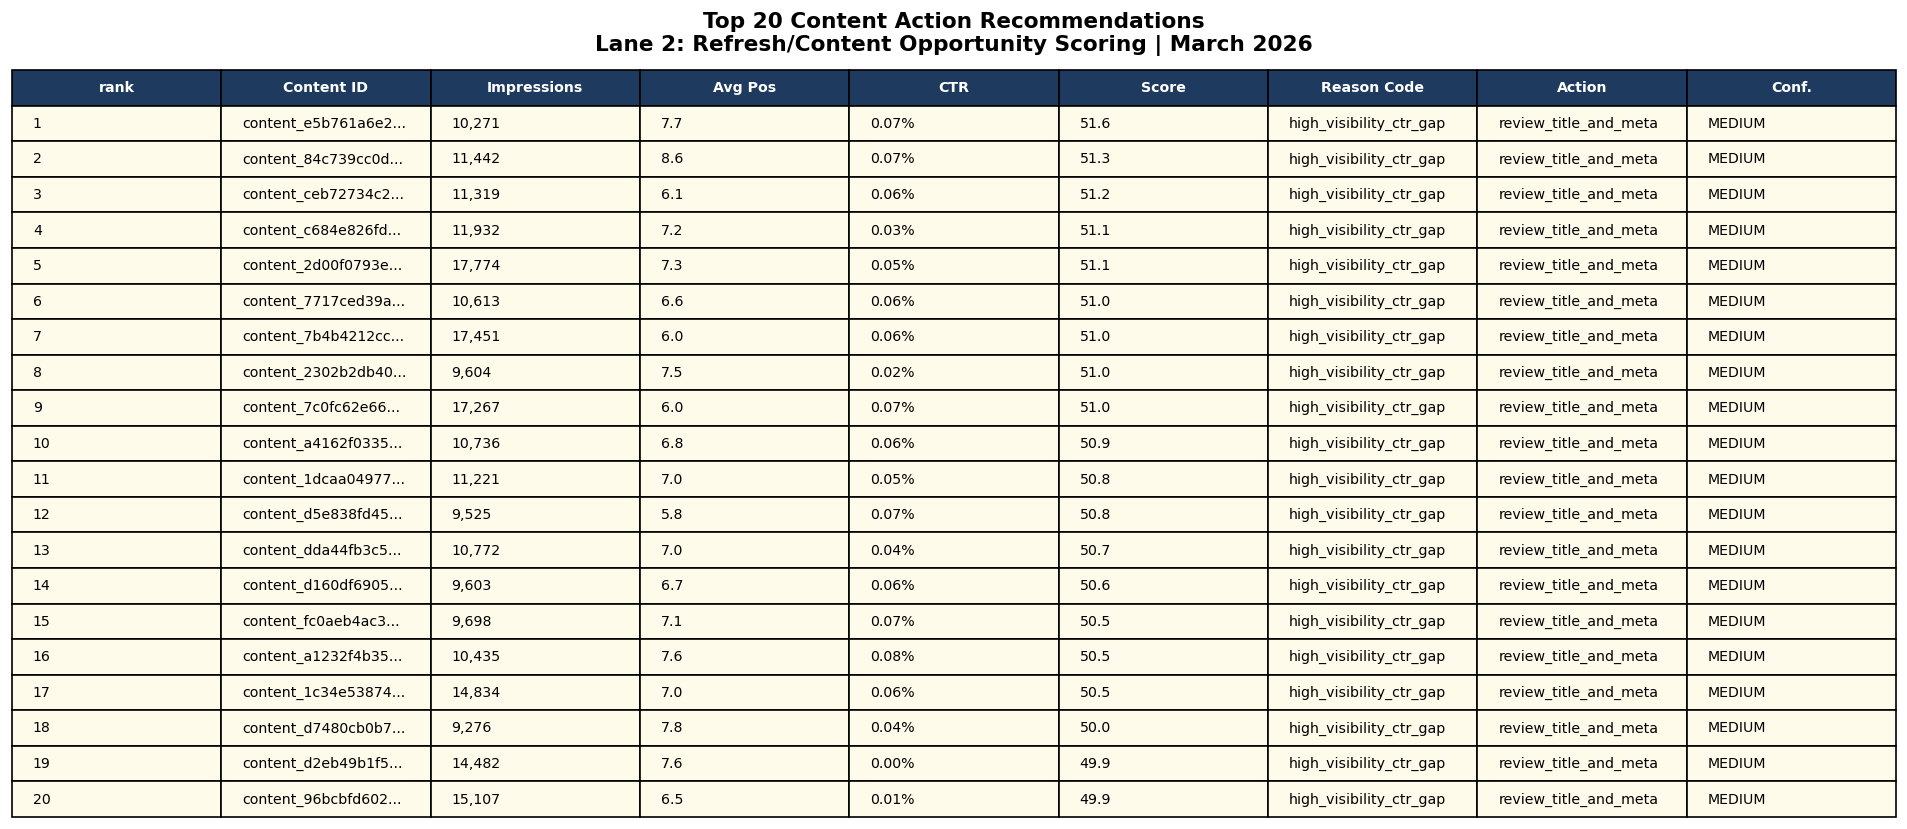

Figure saved: work/figures/top20_preview.png ✅


In [7]:
# ── FIGURE 3: Top-20 Preview Table ──
top20 = playbook_df[export_cols].head(20).copy()
top20.index = range(1, 21)
top20['rank'] = top20.index
top20['content_id_short'] = top20['content_hash_id'].str[:18] + '...'
top20['imp'] = top20['impressions_monthly'].apply(lambda x: f"{x:,.0f}")
top20['pos'] = top20['avg_position'].apply(lambda x: f"{x:.1f}")
top20['ctr_pct'] = top20['ctr'].apply(lambda x: f"{x*100:.2f}%")
top20['score'] = top20['final_score'].apply(lambda x: f"{x:.1f}")

display_cols = ['rank','content_id_short','imp','pos','ctr_pct',
                'score','reason_code','action','confidence']
display_df = top20[display_cols].rename(columns={
    'content_id_short': 'Content ID',
    'imp':              'Impressions',
    'pos':              'Avg Pos',
    'ctr_pct':          'CTR',
    'score':            'Score',
    'reason_code':      'Reason Code',
    'action':           'Action',
    'confidence':       'Conf.'
})

fig, ax = plt.subplots(figsize=(16, 7))
ax.axis('off')

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='left',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.6)

# Style header
for j in range(len(display_df.columns)):
    table[0, j].set_facecolor('#1E3A5F')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Colour rows by confidence
conf_colors = {'HIGH': '#FEF2F2', 'MEDIUM': '#FFFBEB', 'LOW': '#F0FDF4'}
for i in range(1, 21):
    conf = display_df['Conf.'].iloc[i-1]
    row_color = conf_colors.get(conf, '#FFFFFF')
    for j in range(len(display_df.columns)):
        table[i, j].set_facecolor(row_color)

ax.set_title('Top 20 Content Action Recommendations\nLane 2: Refresh/Content Opportunity Scoring | March 2026',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('work/figures/top20_preview.png', bbox_inches='tight', dpi=120)
plt.show()
print("Figure saved: work/figures/top20_preview.png ✅")

In [8]:
# ── METRICS JSON — commit this ──
action_counts    = playbook_df['action'].value_counts().to_dict()
archetype_counts_dict = playbook_df['archetype'].value_counts().to_dict()
confidence_counts = playbook_df['confidence'].value_counts().to_dict()

high_conf = playbook_df[playbook_df['confidence']=='HIGH']
actionable = playbook_df[playbook_df['action'].isin(
    ['review_title_and_meta','review_content_depth']
)]

playbook_metrics = {
    "assignment":    "ML-10 Content Action Playbook",
    "month":         "2026-03",
    "model":         "Random Forest (200 trees, client-holdout validated)",
    "validation": {
        "precision_at_50": round(p50, 3),
        "roc_auc":         round(auc, 3),
        "split":           "client-holdout (20% test clients)"
    },
    "queue_summary": {
        "total_pages_scored":       int(len(playbook_df)),
        "actionable_pages":         int(len(actionable)),
        "high_confidence_flags":    int(len(high_conf)),
        "score_p50":                round(float(playbook_df['final_score'].quantile(0.50)), 2),
        "score_p80":                round(float(playbook_df['final_score'].quantile(0.80)), 2),
        "score_max":                round(float(playbook_df['final_score'].max()), 2)
    },
    "action_counts":    action_counts,
    "archetype_counts": archetype_counts_dict,
    "confidence_counts": confidence_counts,
    "monitoring": {
        "retrain_trigger_precision_threshold": 0.55,
        "retrain_trigger_months_max":          3,
        "false_positive_review_threshold_pct": 40
    },
    "no_go_cases": [
        "Automated title/meta rewrites",
        "Automated content deletions or redirects",
        "Actions on pages below minimum volume gate (impressions < 500)",
        "Using playbook as a performance review tool",
        "Acting on model score alone without checking reason code"
    ],
    "exports": {
        "queue_csv":         "work/outputs/playbook_queue.csv",
        "figure_scores":     "work/figures/score_distribution.png",
        "figure_archetypes": "work/figures/archetype_counts.png",
        "figure_top20":      "work/figures/top20_preview.png",
        "metrics_json":      "work/outputs/playbook_metrics.json"
    }
}

with open('work/outputs/playbook_metrics.json', 'w') as f:
    json.dump(playbook_metrics, f, indent=2)

print("Metrics JSON saved: work/outputs/playbook_metrics.json ✅")
print()
print(json.dumps(playbook_metrics, indent=2))

Metrics JSON saved: work/outputs/playbook_metrics.json ✅

{
  "assignment": "ML-10 Content Action Playbook",
  "month": "2026-03",
  "model": "Random Forest (200 trees, client-holdout validated)",
  "validation": {
    "precision_at_50": 0.52,
    "roc_auc": 0.621,
    "split": "client-holdout (20% test clients)"
  },
  "queue_summary": {
    "total_pages_scored": 34871,
    "actionable_pages": 13220,
    "high_confidence_flags": 0,
    "score_p50": 24.64,
    "score_p80": 32.07,
    "score_max": 51.63
  },
  "action_counts": {
    "no_action": 16206,
    "review_title_and_meta": 12036,
    "monitor_and_flag": 4498,
    "review_content_depth": 1184,
    "monitor": 853,
    "investigate_indexing": 94
  },
  "archetype_counts": {
    "low_visibility": 16206,
    "page_one_low_ctr": 10391,
    "emerging_low_ctr": 4498,
    "visible_low_ctr": 1645,
    "visible_low_engagement": 1184,
    "visible_performing": 853,
    "inconsistent_visible": 94
  },
  "confidence_counts": {
    "LOW": 2165

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## Section 6: Self-Check

- [x] Ranked actions defined with reason codes for every archetype
- [x] Archetype → action mapping table complete
- [x] Decay/refresh insight explained: why page_one_low_ctr is the
      highest-priority archetype and the most actionable fix
- [x] Intended use stated clearly: decision-support for human reviewers,
      not automated execution
- [x] Five hard limits named: causality, SERP layout, intent types,
      data scope, non-production status
- [x] Human review rules written: 4 rules that must be followed before
      any action is taken
- [x] No-go list complete: 5 things that must NOT be automated
- [x] Monitoring checks defined: 4 monthly checks
- [x] Retrain triggers defined: 5 specific conditions
- [x] Queue CSV exported to work/outputs/playbook_queue.csv
- [x] Three figures exported to work/figures/
- [x] Metrics JSON exported to work/outputs/playbook_metrics.json
- [x] No client names, domains, URLs, or private queries in any output
- [x] All claims use safe language: observed, directional, decision-support,
      associated with — never proves, causes, or guarantees
- [x] This playbook is practical and non-production — it is a
      research deliverable, not a deployed system